This project uses the *Mushroom Classification Dataset* from the UCI Machine Learning Repository to classify mushrooms as *edible (e) or poisonous (p)* using the *Naive Bayes algorithm*.

In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
# Load and Explore Data

data = pd.read_csv("/content/mushrooms.csv")
print(data.head())
print("\nMissing values:\n", data.isnull().sum())
print("\nClass distribution:\n", data['class'].value_counts())

  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1       

In [5]:
### *Step 3: Preprocessing (Encoding Categorical Data)

# Since all features are categorical, we use Label Encoding:


label_encoder = LabelEncoder()
for column in data.columns:
    data[column] = label_encoder.fit_transform(data[column])

X = data.drop('class', axis=1)  # Features
y = data['class']  # Target

In [6]:
#  Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Train Naive-Bayes Model

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [11]:
# Evaluate Model

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8073846153846154

Confusion Matrix:
 [[792  51]
 [262 520]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.94      0.84       843
           1       0.91      0.66      0.77       782

    accuracy                           0.81      1625
   macro avg       0.83      0.80      0.80      1625
weighted avg       0.83      0.81      0.80      1625



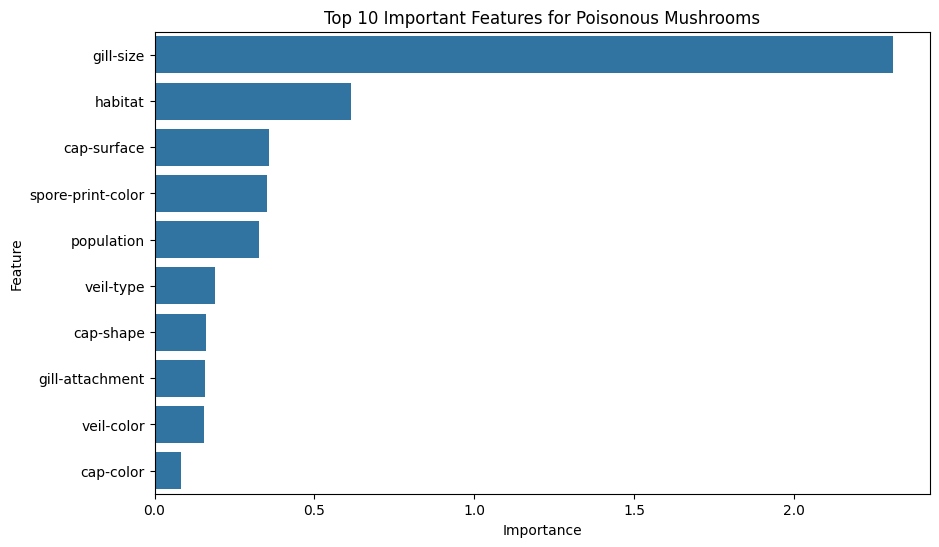

In [10]:
# Feature importance

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_log_prob_[1] - model.feature_log_prob_[0]
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title("Top 10 Important Features for Poisonous Mushrooms")
plt.show()